Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape : (2423, 20)

Distribution des cibles :
x_wins  is_draw
1       0          1830
0       1           441
        0           152
Name: count, dtype: int64

Train : 1938 | Test : 485


✅ Dossiers créés :
   /content/drive/MyDrive/Colab Notebooks/content/models/
   /content/drive/MyDrive/Colab Notebooks/content/ressources/



  LogReg — x_wins
  Accuracy : 0.7753  |  F1-Score : 0.7111
              precision    recall  f1-score   support

           0       0.73      0.13      0.23       119
           1       0.78      0.98      0.87       366

    accuracy                           0.78       485
   macro avg       0.75      0.56      0.55       485
weighted avg       0.77      0.78      0.71       485


  LogReg — is_draw
  Accuracy : 0.8186  |  F1-Score : 0.7369
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       397
           1       0.00      0.00      0.00        88

    accuracy                           0.82       485
   macro avg       0.41      0.50      0.45       485
weighted avg       0.67      0.82      0.74       485



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


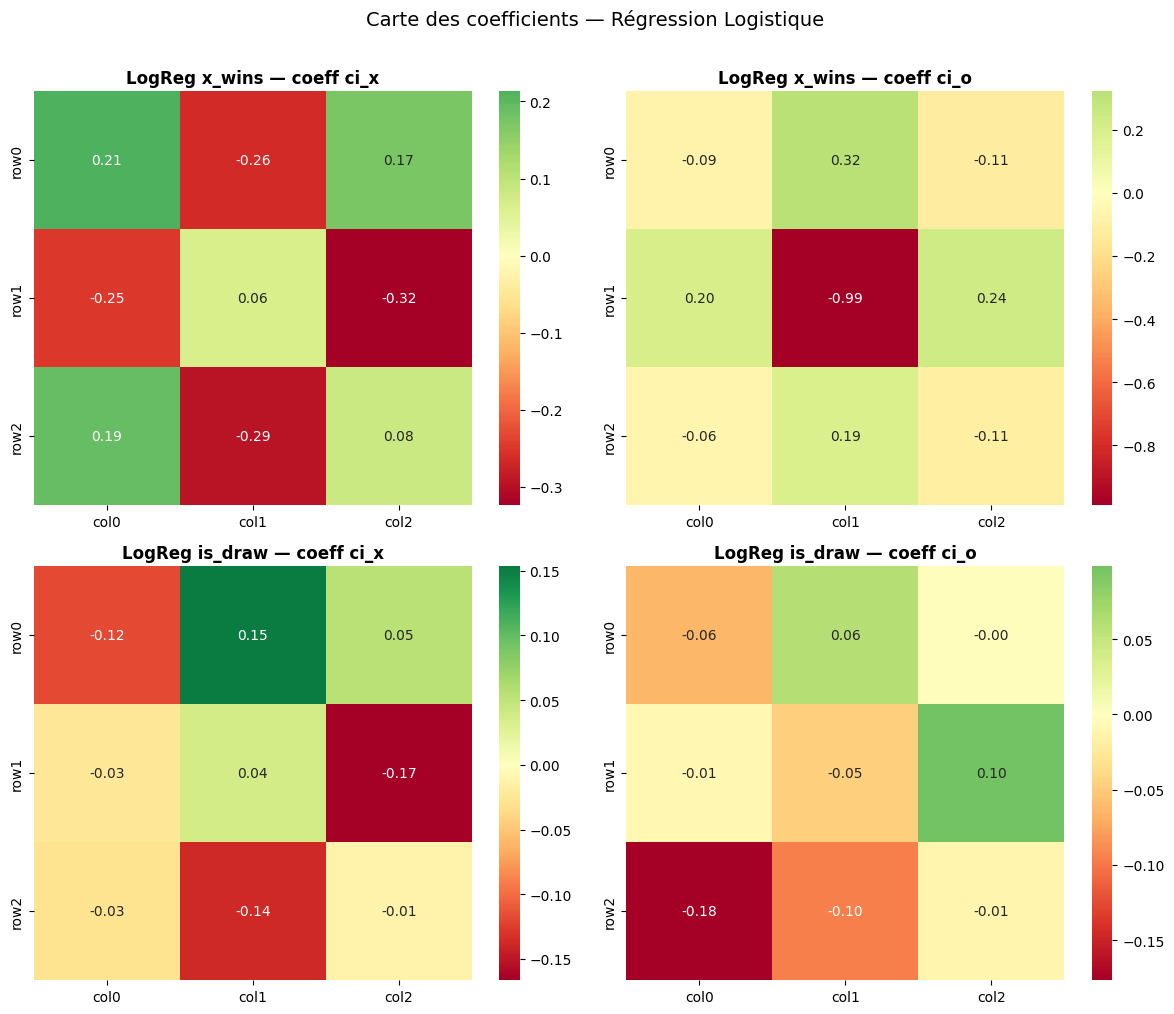

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf_wins = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_wins.fit(X_train, yw_train)
results['RF_xwins'] = evaluate("Random Forest — x_wins", yw_test, rf_wins.predict(X_test))

rf_draw = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_draw.fit(X_train, yd_train)
results['RF_draw'] = evaluate("Random Forest — is_draw", yd_test, rf_draw.predict(X_test))


  Random Forest — x_wins
  Accuracy : 0.8722  |  F1-Score : 0.8563
              precision    recall  f1-score   support

           0       0.97      0.50      0.66       119
           1       0.86      0.99      0.92       366

    accuracy                           0.87       485
   macro avg       0.91      0.75      0.79       485
weighted avg       0.89      0.87      0.86       485


  Random Forest — is_draw
  Accuracy : 0.8165  |  F1-Score : 0.7359
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       397
           1       0.00      0.00      0.00        88

    accuracy                           0.82       485
   macro avg       0.41      0.50      0.45       485
weighted avg       0.67      0.82      0.74       485



In [27]:
!pip install xgboost --quiet
from xgboost import XGBClassifier

xgb_wins = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                          eval_metric='logloss', random_state=42, verbosity=0)
xgb_wins.fit(X_train, yw_train)
results['XGB_xwins'] = evaluate("XGBoost — x_wins", yw_test, xgb_wins.predict(X_test))

xgb_draw = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1,
                          eval_metric='logloss', random_state=42, verbosity=0)
xgb_draw.fit(X_train, yd_train)
results['XGB_draw'] = evaluate("XGBoost — is_draw", yd_test, xgb_draw.predict(X_test))


  XGBoost — x_wins
  Accuracy : 0.8330  |  F1-Score : 0.8157
              precision    recall  f1-score   support

           0       0.78      0.45      0.57       119
           1       0.84      0.96      0.90       366

    accuracy                           0.83       485
   macro avg       0.81      0.70      0.73       485
weighted avg       0.83      0.83      0.82       485


  XGBoost — is_draw
  Accuracy : 0.8165  |  F1-Score : 0.7359
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       397
           1       0.00      0.00      0.00        88

    accuracy                           0.82       485
   macro avg       0.41      0.50      0.45       485
weighted avg       0.67      0.82      0.74       485



In [28]:
from sklearn.neural_network import MLPClassifier

mlp_wins = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                          max_iter=500, random_state=42, early_stopping=True)
mlp_wins.fit(X_train, yw_train)
results['MLP_xwins'] = evaluate("MLP — x_wins", yw_test, mlp_wins.predict(X_test))

mlp_draw = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                          max_iter=500, random_state=42, early_stopping=True)
mlp_draw.fit(X_train, yd_train)
results['MLP_draw'] = evaluate("MLP — is_draw", yd_test, mlp_draw.predict(X_test))


  MLP — x_wins
  Accuracy : 0.8887  |  F1-Score : 0.8828
              precision    recall  f1-score   support

           0       0.87      0.65      0.74       119
           1       0.89      0.97      0.93       366

    accuracy                           0.89       485
   macro avg       0.88      0.81      0.83       485
weighted avg       0.89      0.89      0.88       485


  MLP — is_draw
  Accuracy : 0.8186  |  F1-Score : 0.7369
              precision    recall  f1-score   support

           0       0.82      1.00      0.90       397
           1       0.00      0.00      0.00        88

    accuracy                           0.82       485
   macro avg       0.41      0.50      0.45       485
weighted avg       0.67      0.82      0.74       485



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


       Modèle   Cible  Accuracy  F1-Score
       LogReg  x_wins    0.7753    0.7111
       LogReg is_draw    0.8186    0.7369
Random Forest  x_wins    0.8722    0.8563
Random Forest is_draw    0.8165    0.7359
      XGBoost  x_wins    0.8330    0.8157
      XGBoost is_draw    0.8165    0.7359
          MLP  x_wins    0.8887    0.8828
          MLP is_draw    0.8186    0.7369


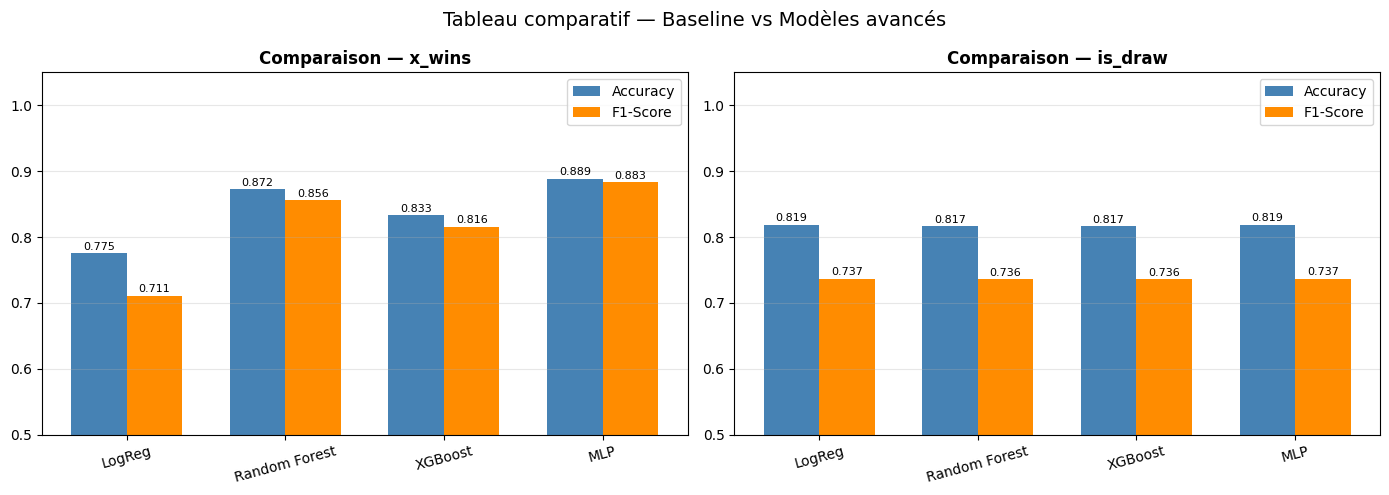

In [29]:
rows = []
for key, r in results.items():
    target = 'x_wins' if 'xwins' in key else 'is_draw'
    model  = r['model'].split('—')[0].strip()
    rows.append({'Modèle': model, 'Cible': target,
                 'Accuracy': round(r['accuracy'], 4),
                 'F1-Score': round(r['f1'], 4)})

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, target in zip(axes, ['x_wins', 'is_draw']):
    sub = df_results[df_results['Cible'] == target]
    x = range(len(sub))
    w = 0.35
    b1 = ax.bar([i-w/2 for i in x], sub['Accuracy'], w, label='Accuracy', color='steelblue')
    b2 = ax.bar([i+w/2 for i in x], sub['F1-Score'], w, label='F1-Score',  color='darkorange')
    ax.set_title(f"Comparaison — {target}", fontweight='bold')
    ax.set_xticks(list(x))
    ax.set_xticklabels(sub['Modèle'], rotation=15)
    ax.set_ylim(0.5, 1.05)
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    for b in list(b1)+list(b2):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f'{b.get_height():.3f}', ha='center', fontsize=8)

plt.suptitle("Tableau comparatif — Baseline vs Modèles avancés", fontsize=14)
plt.tight_layout()
plt.savefig(f'{BASE}/ressources/comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import joblib

joblib.dump(lr_wins,  f'{BASE}/models/lr_xwins.joblib')
joblib.dump(lr_draw,  f'{BASE}/models/lr_draw.joblib')
joblib.dump(rf_wins,  f'{BASE}/models/rf_xwins.joblib')
joblib.dump(rf_draw,  f'{BASE}/models/rf_draw.joblib')
joblib.dump(xgb_wins, f'{BASE}/models/xgb_xwins.joblib')
joblib.dump(xgb_draw, f'{BASE}/models/xgb_draw.joblib')
joblib.dump(mlp_wins, f'{BASE}/models/mlp_xwins.joblib')
joblib.dump(mlp_draw, f'{BASE}/models/mlp_draw.joblib')

print("✅ Tous les modèles sauvegardés !")
print(f"\nFichiers dans {BASE}/models/ :")
for f in sorted(os.listdir(f'{BASE}/models')):
    print(f"   📦 {f}")

✅ Tous les modèles sauvegardés !

Fichiers dans /content/drive/MyDrive/Colab Notebooks/content/models/ :
   📦 lr_draw.joblib
   📦 lr_xwins.joblib
   📦 mlp_draw.joblib
   📦 mlp_xwins.joblib
   📦 rf_draw.joblib
   📦 rf_xwins.joblib
   📦 xgb_draw.joblib
   📦 xgb_xwins.joblib
